In [ ]:
import numpy as np
import pandas as pd
import warnings
from scipy.stats import kendalltau
from scipy.stats import expon, kstest
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader, random_split, WeightedRandomSampler
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

DATASET_PATH = r'..\Dataset\NHL_Clean_Shots\processed.csv'

In [48]:
df = pd.read_csv(DATASET_PATH)

# Absolute game clock: second 0 = puck drop, counts up through all periods
df['period_seconds_elapsed'] = 1200 - df['periodTimeRemaining']
df["game_seconds"] = (df["period"].clip(upper=4) - 1) * 1200 + df["period_seconds_elapsed"]

df = df.sort_values(["gameId", "sortOrder"]).reset_index(drop=True)

print(f"Loaded {len(df):,} rows, {df['gameId'].nunique():,} games, and {df['season'].nunique()} seasons")

Loaded 528,720 rows, 6,116 games, and 5 seasons


In [49]:
# Generating previous event features by merging the dataframe with a shifted version of itself

prev = df[["gameId","sortOrder","game_seconds","xCoord","yCoord","eventType"]].copy()
prev.columns = ["gameId","sortOrder","prev_game_seconds","prev_x","prev_y","prev_event_type"]
prev["sortOrder"] = prev["sortOrder"] + 1

df = df.merge(prev, on=["gameId","sortOrder"], how="left")

df['time_since_last_event'] = df.groupby(['gameId', 'period'])['periodTimeRemaining'].diff().fillna(0)
first_event_mask = df.groupby("gameId")["sortOrder"].transform("min") == df["sortOrder"]
df.loc[first_event_mask, ["feat_time_since_last_event","prev_x","prev_y","prev_event_type"]] = np.nan

In [50]:
# Trivial processing of preiod-specific features, inferrable from existing columns, saved for convinience and clarity in modeling stage 

df["feat_period_seconds"]     = df["period_seconds_elapsed"]
df["feat_game_seconds"]       = df["game_seconds"]

df["feat_period_fraction"]    = df["period_seconds_elapsed"] / 1200
df["feat_regulation_fraction"] = df["game_seconds"] / 3600

df["feat_is_overtime"]         = (df["period"] > 3).astype(int)
df["feat_is_late_regulation"]  = (
    (df["period"] == 3) & (df["period_seconds_elapsed"] >= 900)
).astype(int)                                         

df["feat_is_early_period"]     = (df["period_seconds_elapsed"] < 120).astype(int)  # first 2 min

for p in [1, 2, 3]:
    df[f"feat_period_{p}"] = (df["period"] == p).astype(int)

df["feat_game_quintile"] = pd.cut(
    df["game_seconds"].clip(0, 3600),
    bins=[0, 720, 1440, 2160, 2880, 3600],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
).astype(float)

In [51]:
# Converting time since last event to log scale (with a small offset to avoid log(0)) to reduce skew and handle wide range of values
# In addition, calculation of puck speed proxy and rebound flag, which are discriminative features for shot events and depend on the timing 
# and nature of the previous event

df["feat_time_since_last_log"] = np.log1p(df["feat_time_since_last_event"])

puck_dx = df["xCoord"].fillna(0) - df["prev_x"].fillna(df["xCoord"].fillna(0))
puck_dy = df["yCoord"].fillna(0) - df["prev_y"].fillna(df["yCoord"].fillna(0))
puck_dist = np.sqrt(puck_dx**2 + puck_dy**2)
elapsed   = df["feat_time_since_last_event"].replace(0, np.nan)


EVENT_TYPES = ["shot-on-goal","goal","missed-shot"]

for et in EVENT_TYPES:
    col = "feat_prev_" + et.replace("-","_")
    df[col] = (df["prev_event_type"] == et).astype(int)

df["feat_prev_was_goal"] = (
    df["prev_event_type"].isin(["goal"])
).astype(int)

print(df[["feat_time_since_last_event","feat_prev_was_goal"]].describe().round(2))

       feat_time_since_last_event  feat_prev_was_goal
count                         0.0           528720.00
mean                          NaN                0.00
std                           NaN                0.04
min                           NaN                0.00
25%                           NaN                0.00
50%                           NaN                0.00
75%                           NaN                0.00
max                           NaN                1.00


In [52]:
# For each shot, count how many shots by the same team occurred in the preceding N seconds within the same game by the same team for each event.

def team_shot_count(group, window_seconds):
    results = np.zeros(len(group), dtype=int)
    times = group["game_seconds"].values
    event_types = group["eventType"].values
    owner = group["eventOwnerTeamId"].values

    for i in range(len(group)):
        t_now = times[i]
        team_now = owner[i]
        window_mask = (
            (times >= t_now - window_seconds) &
            (times < t_now) &
            (owner == team_now) &
            (np.isin(event_types, EVENT_TYPES)) 
        )
        results[i] = window_mask.sum()
    return results

for window, label in [(60, "60s"), (120, "2min"), (300, "5min")]:
    col = f"feat_goal_count_{label}"
    print(f"Computing for shots within {window}s previous")
    counts = []
    for _, grp in df.groupby("gameId", sort=False):
        counts.extend(team_shot_count(grp, window))
    df[col] = counts
    print(f"mean={df[col].mean():.2f}  max={df[col].max()}\n")

Computing for shots within 60s previous
mean=0.88  max=10

Computing for shots within 120s previous
mean=1.60  max=13

Computing for shots within 300s previous
mean=3.60  max=19



In [53]:
# Generating lagged event sequences of lengths 2 and 3 to capture local event patterns that may influence shot outcomes.
for lag in [1, 2, 3]:
    df[f"event_lag_{lag}"] = df.groupby("gameId")["eventType"].shift(lag)

df["feat_bigram"] = (
    df["event_lag_1"].fillna("START") + "_" + df["eventType"]
)

df["feat_trigram"] = (
    df["event_lag_2"].fillna("START") + "_" +
    df["event_lag_1"].fillna("START") + "_" +
    df["eventType"]
)

shots_only = df[df["eventType"].isin(["shot-on-goal","goal"])].copy()

bigram_goal_rate = (
    shots_only.groupby("feat_bigram")["is_goal"]
    .agg(["mean","count"])
    .query("count >= 30")        
    .sort_values("mean", ascending=False)
    .rename(columns={"mean":"goal_rate","count":"n_shots"})
)

print(bigram_goal_rate.head(15).round(4).to_string())

trigram_goal_rate = (
    shots_only.groupby("feat_trigram")["is_goal"]
    .agg(["mean", "count"])
    .query("count >= 30")        
    .sort_values("mean", ascending=False)
    .rename(columns={"mean": "goal_rate", "count": "n_shots"})
)

print("\nTop 15 Trigram Sequences by Goal Rate:")
print(trigram_goal_rate.head(15).round(4).to_string())

                           goal_rate  n_shots
feat_bigram                                  
START_goal                       1.0      305
goal_goal                        1.0     2416
shot-on-goal_goal                1.0    24586
missed-shot_goal                 1.0    11055
goal_shot-on-goal                0.0    23339
START_shot-on-goal               0.0     3950
missed-shot_shot-on-goal         0.0    95874
shot-on-goal_shot-on-goal        0.0   211658

Top 15 Trigram Sequences by Goal Rate:
                                 goal_rate  n_shots
feat_trigram                                       
START_START_goal                       1.0      305
START_missed-shot_goal                 1.0       90
START_shot-on-goal_goal                1.0      222
goal_goal_goal                         1.0      199
shot-on-goal_missed-shot_goal          1.0     6769
missed-shot_goal_goal                  1.0      659
missed-shot_missed-shot_goal           1.0     3463
goal_shot-on-goal_goal          

In [81]:
df.to_csv(r'..\Dataset\NHL_Clean_Shots\processed.csv', index=False)

In [55]:
season_stats = (
    df.groupby("season")
    .agg(
        total_shots   = ("gameId", "count"), 
        total_goals   = ("is_goal", "sum"),
        total_games   = ("gameId", "nunique"),
    )
    .reset_index()
)

season_stats["shots_per_game"] = season_stats["total_shots"] / season_stats["total_games"]
season_stats["goals_per_game"] = season_stats["total_goals"] / season_stats["total_games"]
season_stats["goal_conversion"] = season_stats["total_goals"] / season_stats["total_shots"]

print(season_stats.to_string(index=False))

x_rank = np.arange(len(season_stats))
tau_s, p_s = kendalltau(x_rank, season_stats["shots_per_game"].values)
print(f"\nMann-Kendall (shots/game): tau={tau_s:.3f}  p={p_s:.4f}")

tau_c, p_c = kendalltau(x_rank, season_stats["goal_conversion"].values)
print(f"Mann-Kendall (goal conv.): tau={tau_c:.3f}  p={p_c:.4f}")

   season  total_shots  total_goals  total_games  shots_per_game  goals_per_game  goal_conversion
2020.2021        71759         5176          868       82.671659        5.963134         0.072130
2021.2022       114037         8374         1312       86.918445        6.382622         0.073432
2022.2023       114733         8474         1312       87.448933        6.458841         0.073858
2023.2024       115446         8268         1312       87.992378        6.301829         0.071618
2024.2025       112745         8070         1312       85.933689        6.150915         0.071577

Mann-Kendall (shots/game): tau=0.400  p=0.4833
Mann-Kendall (goal conv.): tau=-0.400  p=0.4833


In [58]:
temporal_feat_cols = [
    c for c in df.columns 
    if c.startswith("feat_") and pd.api.types.is_numeric_dtype(df[c])
]

print(f"Total temporal features found: {len(temporal_feat_cols)}\n")

corr = (
    df[temporal_feat_cols + ["is_goal"]]
    .corr()["is_goal"]
    .drop("is_goal")
    .abs()
    .sort_values(ascending=False)
)

print("Correlation with Goal Outcome (Absolute Value):")
print(corr.round(4).to_string())

Total temporal features found: 20

Correlation with Goal Outcome (Absolute Value):
feat_is_overtime              0.0618
feat_prev_shot_on_goal        0.0572
feat_game_seconds             0.0483
feat_regulation_fraction      0.0483
feat_is_late_regulation       0.0400
feat_game_quintile            0.0358
feat_period_fraction          0.0353
feat_period_seconds           0.0353
feat_prev_was_goal            0.0343
feat_prev_goal                0.0343
feat_period_1                 0.0243
feat_goal_count_60s           0.0194
feat_prev_missed_shot         0.0153
feat_goal_count_2min          0.0149
feat_period_3                 0.0121
feat_is_early_period          0.0111
feat_goal_count_5min          0.0081
feat_period_2                 0.0055
feat_time_since_last_event       NaN
feat_time_since_last_log         NaN


In [82]:
SEQ_FEATURES = [
    "feat_game_seconds",
    "feat_period_fraction",
    "feat_time_since_last_event",
    "feat_time_since_last_log",
    "feat_goal_count_60s",  
    "feat_goal_count_2min", 
    "feat_goal_count_5min",
    "feat_period_1", "feat_period_2", "feat_period_3",
    "feat_is_overtime",
    "feat_is_late_regulation",
    "shot_type_int"  
]

shot_type_map = {s: i for i, s in enumerate(df["shotType"].dropna().unique())}
df["shot_type_int"] = df["shotType"].map(shot_type_map).fillna(0).astype(int)

TARGET = "is_goal"
MAX_SEQ_LEN = 60        

shot_df = df[df["eventType"].isin(["shot-on-goal", "goal"])].copy()
shot_df[SEQ_FEATURES] = shot_df[SEQ_FEATURES].fillna(0)

sequences, labels = [], []

for game_id, grp in shot_df.groupby("gameId"):
    grp = grp.sort_values("sortOrder")
    feat_matrix = grp[SEQ_FEATURES].values.astype(np.float32)
    target_vec  = grp[TARGET].values.astype(np.float32)

    L = len(feat_matrix)
    if L > MAX_SEQ_LEN:
        feat_matrix = feat_matrix[-MAX_SEQ_LEN:]   
        target_vec  = target_vec[-MAX_SEQ_LEN:]
        L = MAX_SEQ_LEN

    pad = MAX_SEQ_LEN - L
    if pad > 0:
        feat_matrix = np.vstack([np.zeros((pad, len(SEQ_FEATURES))), feat_matrix])
        target_vec  = np.concatenate([np.zeros(pad), target_vec])

    sequences.append(feat_matrix)
    labels.append(target_vec)

X_seq = np.array(sequences, dtype=np.float32)   
y_seq = np.array(labels,    dtype=np.float32)    

print(f"X_seq shape: {X_seq.shape}  — (games, timesteps, features)")
print(f"y_seq shape: {y_seq.shape}")
print(f"Goal rate in sequences: {y_seq.mean():.4f}")

X_seq shape: (6116, 60, 13)  — (games, timesteps, features)
y_seq shape: (6116, 60)
Goal rate in sequences: 0.0992


In [ ]:
N, T, F = X_seq.shape
X_flat = X_seq.reshape(-1, F)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat).reshape(N, T, F)

X_t = torch.tensor(X_scaled, dtype=torch.float32)
y_t = torch.tensor(y_seq[:, -1], dtype=torch.float32) 

dataset = TensorDataset(X_t, y_t)
n_train = int(0.8 * len(dataset))
n_val = len(dataset) - n_train
train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))

game_has_goal = (y_seq.sum(axis=1) > 0).astype(int)
game_weights = 1. / np.bincount(game_has_goal)
sample_weights = game_weights[game_has_goal]
train_weights = sample_weights[train_ds.indices]

sampler = WeightedRandomSampler(train_weights, len(train_weights))
train_dl = DataLoader(train_ds, batch_size=128, sampler=sampler) 
val_dl = DataLoader(val_ds, batch_size=256)

class ShotLSTM(nn.Module):
    def __init__(self, input_size, hidden=128, layers=2, dropout=0.4):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers=layers, 
                            batch_first=True, dropout=dropout, bidirectional=False)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = torch.mean(out, dim=1) 
        return self.head(out).squeeze(-1)

device = "cuda" if torch.cuda.is_available() else "cpu"
model_lstm = ShotLSTM(input_size=F).to(device)

pos_weight = torch.tensor([(len(y_np_flat) - y_np_flat.sum()) / y_np_flat.sum()]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model_lstm.parameters(), lr=5e-4, weight_decay=1e-5)

history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

for epoch in range(15): 
    model_lstm.train()
    train_loss = 0
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_lstm(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(Xb)

    model_lstm.eval()
    val_loss, all_preds, all_targets = 0, [], []
    with torch.no_grad():
        for Xb, yb in val_dl:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model_lstm(Xb)
            val_loss += criterion(logits, yb).item() * len(Xb)
            all_preds.extend(torch.sigmoid(logits).cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

    val_auc = roc_auc_score(all_targets, all_preds)
    history['train_loss'].append(train_loss / n_train)
    history['val_loss'].append(val_loss / n_val)
    history['val_auc'].append(val_auc)

    print(f"Epoch {epoch+1:02d} | Train: {history['train_loss'][-1]:.4f} | Val AUC: {val_auc:.4f}")

torch.save(model_lstm.state_dict(), "shot_lstm_model.pth")

Epoch 01 | Train: 2.4887 | Val AUC: 0.5636
Epoch 02 | Train: 2.0056 | Val AUC: 0.6006
Epoch 03 | Train: 1.7597 | Val AUC: 0.6571
Epoch 04 | Train: 1.6620 | Val AUC: 0.6888
Epoch 05 | Train: 1.6135 | Val AUC: 0.6935
Epoch 06 | Train: 1.5440 | Val AUC: 0.7029
Epoch 07 | Train: 1.4994 | Val AUC: 0.7197
Epoch 08 | Train: 1.5234 | Val AUC: 0.7178
Epoch 09 | Train: 1.5066 | Val AUC: 0.7280
Epoch 10 | Train: 1.4595 | Val AUC: 0.7478
Epoch 11 | Train: 1.4592 | Val AUC: 0.7527
Epoch 12 | Train: 1.4571 | Val AUC: 0.7619
Epoch 13 | Train: 1.4557 | Val AUC: 0.7796
Epoch 14 | Train: 1.4071 | Val AUC: 0.8030
Epoch 15 | Train: 1.3994 | Val AUC: 0.7844


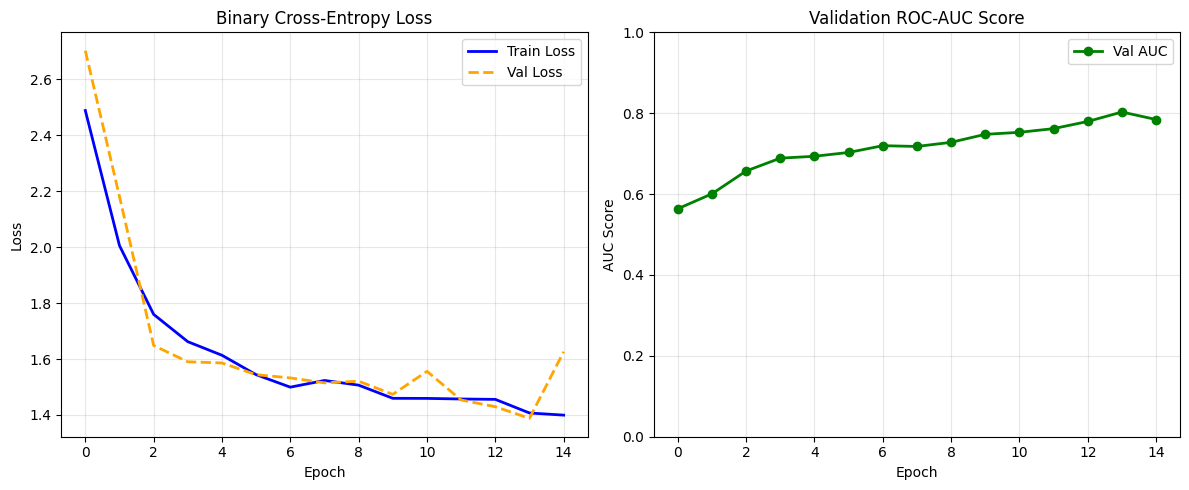

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', lw=2)
plt.plot(history['val_loss'], label='Val Loss', color='orange', linestyle='--', lw=2)
plt.title('Binary Cross-Entropy Loss', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend() 

plt.subplot(1, 2, 2)
plt.plot(history['val_auc'], label='Val AUC', color='green', marker='o', lw=2)
plt.title('Validation ROC-AUC Score', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('AUC Score')
plt.ylim([0, 1.0]) 
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()